# 09 — Linear Regression with MLflow

**Student:** Nosirov Nodir  
**Group:** Tulpar

This notebook trains the first course model on the complete model-ready training split, evaluates it on the later validation split, and records the experiment in MLflow. Test targets remain untouched.

## 1. Experiment design

Linear Regression is an understandable first model. It uses the 20 numeric, leakage-safe features from notebook 07. Standardization puts differently scaled inputs on comparable scales. Negative raw predictions are clipped to zero because product demand cannot be negative; the number of affected rows is reported.

In [1]:
from pathlib import Path
import platform
import time

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from mlflow.models import infer_signature
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path("/content/retail-demand-forecasting")]
    for candidate in candidates:
        feature_dir = candidate / "data" / "processed" / "m5_foods_features"
        if (feature_dir / "train.parquet").exists() and (feature_dir / "validation.parquet").exists():
            return candidate.resolve()
    raise FileNotFoundError("Feature files were not found. Run notebook 07 first.")

PROJECT_ROOT = find_project_root()
FEATURE_DIR = PROJECT_ROOT / "data" / "processed" / "m5_foods_features"
REPORT_DIR = PROJECT_ROOT / "reports"
MLRUNS_DIR = PROJECT_ROOT / "mlruns"
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"
REPORT_DIR.mkdir(exist_ok=True)
MLRUNS_DIR.mkdir(exist_ok=True)
TRACKING_URI = f"sqlite:///{MLFLOW_DB.as_posix()}"

print("Python:", platform.python_version())
print("scikit-learn:", sklearn.__version__)
print("MLflow:", mlflow.__version__)

Python: 3.10.11
scikit-learn: 1.7.2
MLflow: 3.15.0


## 2. Load only train and validation

The test Parquet file is not read. Identifier columns are retained only for grouped evaluation, not as model inputs in this first numeric experiment.

In [2]:
numeric_features = [
    "sales_lag_1", "sales_lag_2", "sales_lag_4", "sales_lag_8",
    "sales_roll_mean_4", "sales_roll_std_4",
    "sales_roll_mean_8", "sales_roll_std_8",
    "zero_weeks_last_4",
    "sell_price_mean", "price_lag_1", "price_change_pct",
    "year", "month", "week_of_year", "quarter",
    "event_days", "has_event", "snap_days", "has_snap",
]
target = "weekly_units_sold"
metadata_columns = ["week_start", "dept_id", "store_id", "dataset_split"]
load_columns = metadata_columns + numeric_features + [target]

train = pd.read_parquet(FEATURE_DIR / "train.parquet", columns=load_columns)
validation = pd.read_parquet(FEATURE_DIR / "validation.parquet", columns=load_columns)

X_train = train[numeric_features].astype("float32")
y_train = train[target].astype("float32")
X_validation = validation[numeric_features].astype("float32")
y_validation = validation[target].astype("float32")

print("Train rows:", f"{len(train):,}")
print("Validation rows:", f"{len(validation):,}")
print("Numeric features:", len(numeric_features))

Train rows: 2,888,944
Validation rows: 57,478
Numeric features: 20


## 3. Train the model

The scaler is fitted on training rows only. Linear Regression then learns one coefficient for each standardized feature.

In [3]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression(copy_X=False, n_jobs=-1)),
])

fit_started = time.perf_counter()
model.fit(X_train, y_train)
fit_seconds = time.perf_counter() - fit_started

predict_started = time.perf_counter()
raw_predictions = model.predict(X_validation)
predict_seconds = time.perf_counter() - predict_started
predictions = np.clip(raw_predictions, 0, None)

print("Fit seconds:", f"{fit_seconds:,.2f}")
print("Validation prediction seconds:", f"{predict_seconds:,.2f}")
print("Raw negative predictions:", int((raw_predictions < 0).sum()))

Fit seconds: 2.35
Validation prediction seconds: 0.01
Raw negative predictions: 3263


## 4. Compare with the approved baseline

The same validation rows and the same MAE/RMSE definitions are used. A positive improvement percentage means the model has lower error than the four-week-mean baseline.

In [4]:
def regression_metrics(actual, predicted):
    error = predicted - actual
    return {
        "mae": float(np.abs(error).mean()),
        "rmse": float(np.sqrt(np.square(error).mean())),
        "mean_error": float(error.mean()),
    }

model_metrics = regression_metrics(y_validation.to_numpy(), predictions)
raw_model_metrics = regression_metrics(y_validation.to_numpy(), raw_predictions)
baseline_report = pd.read_csv(REPORT_DIR / "baseline_metrics_validation.csv")
baseline_reference = baseline_report.loc[baseline_report["baseline"].eq("previous_4_week_mean")].iloc[0]
mae_improvement_pct = 100 * (baseline_reference["mae"] - model_metrics["mae"]) / baseline_reference["mae"]
rmse_improvement_pct = 100 * (baseline_reference["rmse"] - model_metrics["rmse"]) / baseline_reference["rmse"]

experiment_metrics = pd.DataFrame([
    {"method": "previous_4_week_mean", "rows": len(validation), "mae": baseline_reference["mae"], "rmse": baseline_reference["rmse"], "mean_error": baseline_reference["mean_error"]},
    {"method": "linear_regression_clipped", "rows": len(validation), **model_metrics},
]).sort_values("mae").reset_index(drop=True)
display(experiment_metrics)
print("MAE improvement versus baseline (%):", f"{mae_improvement_pct:,.3f}")
print("RMSE improvement versus baseline (%):", f"{rmse_improvement_pct:,.3f}")

,method,rows,mae,rmse,mean_error
0,previous_4_week_mean,57478,4.5172,10.1300,-0.0255
1,linear_regression_clipped,57478,4.7662,10.5693,-0.2911


MAE improvement versus baseline (%): -5.512
RMSE improvement versus baseline (%): -4.337


## 5. Grouped validation review

Store and department metrics use the clipped model predictions. These reports make weak groups visible even if the overall score looks acceptable.

In [5]:
validation_results = validation[["week_start", "store_id", "dept_id", target]].copy()
validation_results["prediction"] = predictions

def grouped_metrics(data, group_column):
    rows = []
    for group_value, group in data.groupby(group_column, observed=True):
        rows.append({
            group_column: group_value,
            "rows": len(group),
            **regression_metrics(group[target].to_numpy(), group["prediction"].to_numpy()),
        })
    return pd.DataFrame(rows).sort_values("mae").reset_index(drop=True)

store_metrics = grouped_metrics(validation_results, "store_id")
department_metrics = grouped_metrics(validation_results, "dept_id")
display(store_metrics)
display(department_metrics)

,store_id,rows,mae,rmse,mean_error
0,CA_4,5748,3.3477,5.6750,-0.2757
1,TX_1,5748,3.7095,7.7018,-0.2878
2,TX_2,5748,4.0883,7.9174,0.3186
3,TX_3,5748,4.2663,9.0564,0.0529
4,WI_1,5748,4.2857,7.7637,-0.1855
5,CA_2,5748,4.7905,9.4673,-0.8929
6,WI_3,5748,4.9829,10.8525,-0.2617
7,CA_1,5747,5.0004,9.9330,-0.6504
8,CA_3,5747,6.3324,14.2754,-0.2575
9,WI_2,5748,6.8582,17.6281,-0.4710


,dept_id,rows,mae,rmse,mean_error
0,FOODS_2,15920,3.6035,7.5574,-0.2332
1,FOODS_1,8640,4.0402,7.2815,0.8793
2,FOODS_3,32918,5.5190,12.3902,-0.6264


## 6. Verification checks

These checks protect the chronological split, row accounting, finite predictions, and exclusion of target and test data. Model improvement is reported as a result, not forced as an assertion.

In [6]:
feature_summary = pd.read_csv(REPORT_DIR / "feature_split_summary.csv").set_index("split")
store_row_total = int(store_metrics["rows"].sum())
department_row_total = int(department_metrics["rows"].sum())
checks = pd.DataFrame([
    {"check": "expected train rows", "status": "PASS" if len(train) == int(feature_summary.loc["train", "rows_after"]) else "FAIL", "details": str(len(train))},
    {"check": "expected validation rows", "status": "PASS" if len(validation) == int(feature_summary.loc["validation", "rows_after"]) else "FAIL", "details": str(len(validation))},
    {"check": "train split only", "status": "PASS" if train["dataset_split"].eq("train").all() else "FAIL", "details": str(train["dataset_split"].unique().tolist())},
    {"check": "validation split only", "status": "PASS" if validation["dataset_split"].eq("validation").all() else "FAIL", "details": str(validation["dataset_split"].unique().tolist())},
    {"check": "chronological split order", "status": "PASS" if train["week_start"].max() < validation["week_start"].min() else "FAIL", "details": "train max < validation min"},
    {"check": "target excluded from model features", "status": "PASS" if target not in numeric_features else "FAIL", "details": target},
    {"check": "model inputs contain no nulls", "status": "PASS" if not X_train.isna().any().any() and not X_validation.isna().any().any() else "FAIL", "details": "train and validation"},
    {"check": "finite raw predictions", "status": "PASS" if np.isfinite(raw_predictions).all() else "FAIL", "details": str(len(raw_predictions))},
    {"check": "non-negative final predictions", "status": "PASS" if (predictions >= 0).all() else "FAIL", "details": "clip at zero"},
    {"check": "store row accounting", "status": "PASS" if store_row_total == len(validation) else "FAIL", "details": str(store_row_total)},
    {"check": "department row accounting", "status": "PASS" if department_row_total == len(validation) else "FAIL", "details": str(department_row_total)},
    {"check": "test file not loaded", "status": "PASS", "details": "train.parquet + validation.parquet"},
])
assert checks["status"].eq("PASS").all()
display(checks)

,check,status,details
0,expected train rows,PASS,2888944
1,expected validation rows,PASS,57478
2,train split only,PASS,['train']
3,validation split only,PASS,['validation']
4,chronological split order,PASS,train max < validation min
5,target excluded from model features,PASS,weekly_units_sold
6,model inputs contain no nulls,PASS,train and validation
7,finite raw predictions,PASS,57478
8,non-negative final predictions,PASS,clip at zero
9,store row accounting,PASS,57478


## 7. Save reports and record MLflow run

MLflow stores experiment metadata in the local ignored `mlflow.db` database and model artifacts in `mlruns/`. Small CSV evidence is committed separately.

In [7]:
regressor = model.named_steps["regressor"]
coefficient_report = pd.DataFrame({
    "feature": numeric_features,
    "standardized_coefficient": regressor.coef_,
})
coefficient_report["absolute_coefficient"] = coefficient_report["standardized_coefficient"].abs()
coefficient_report = coefficient_report.sort_values("absolute_coefficient", ascending=False).reset_index(drop=True)

experiment_metrics.to_csv(REPORT_DIR / "linear_regression_metrics_validation.csv", index=False)
store_metrics.to_csv(REPORT_DIR / "linear_regression_store_metrics_validation.csv", index=False)
department_metrics.to_csv(REPORT_DIR / "linear_regression_department_metrics_validation.csv", index=False)
coefficient_report.to_csv(REPORT_DIR / "linear_regression_coefficients.csv", index=False)
checks.to_csv(REPORT_DIR / "linear_regression_checks.csv", index=False)

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment("retail-demand-forecasting")
signature = infer_signature(X_validation.head(1000), model.predict(X_validation.head(1000)))
input_example = X_validation.head(5)

with mlflow.start_run(run_name="linear-regression-numeric-v1") as run:
    mlflow.log_params({
        "model_type": "LinearRegression",
        "scaler": "StandardScaler",
        "numeric_feature_count": len(numeric_features),
        "train_rows": len(train),
        "validation_rows": len(validation),
        "prediction_floor": 0,
        "target": target,
        "split_strategy": "chronological",
    })
    mlflow.log_metrics({
        "validation_mae": model_metrics["mae"],
        "validation_rmse": model_metrics["rmse"],
        "validation_mean_error": model_metrics["mean_error"],
        "validation_raw_mae": raw_model_metrics["mae"],
        "validation_raw_rmse": raw_model_metrics["rmse"],
        "baseline_mae": float(baseline_reference["mae"]),
        "baseline_rmse": float(baseline_reference["rmse"]),
        "mae_improvement_pct": float(mae_improvement_pct),
        "rmse_improvement_pct": float(rmse_improvement_pct),
        "fit_seconds": float(fit_seconds),
        "predict_seconds": float(predict_seconds),
        "raw_negative_predictions": int((raw_predictions < 0).sum()),
    })
    for report_name in [
        "linear_regression_metrics_validation.csv",
        "linear_regression_store_metrics_validation.csv",
        "linear_regression_department_metrics_validation.csv",
        "linear_regression_coefficients.csv",
        "linear_regression_checks.csv",
    ]:
        mlflow.log_artifact(REPORT_DIR / report_name, artifact_path="reports")
    mlflow.log_text("\n".join(numeric_features), "numeric_features.txt")
    mlflow.sklearn.log_model(model, name="model", signature=signature, input_example=input_example)
    run_id = run.info.run_id

recorded_run = mlflow.get_run(run_id)
reloaded_model = mlflow.sklearn.load_model(f"runs:/{run_id}/model")
reloaded_predictions = np.clip(reloaded_model.predict(X_validation), 0, None)
reloaded_mae = regression_metrics(y_validation.to_numpy(), reloaded_predictions)["mae"]
reload_matches = bool(np.isclose(reloaded_mae, model_metrics["mae"]))
checks = pd.concat([checks, pd.DataFrame([
    {"check": "MLflow run finished", "status": "PASS" if recorded_run.info.status == "FINISHED" else "FAIL", "details": recorded_run.info.status},
    {"check": "MLflow model reload reproduces MAE", "status": "PASS" if reload_matches else "FAIL", "details": f"{reloaded_mae:.6f}"},
])], ignore_index=True)
assert checks["status"].eq("PASS").all()
checks.to_csv(REPORT_DIR / "linear_regression_checks.csv", index=False)
mlflow.tracking.MlflowClient().log_artifact(run_id, REPORT_DIR / "linear_regression_checks.csv", artifact_path="reports")

mlflow_summary = pd.DataFrame([{
    "experiment_name": "retail-demand-forecasting",
    "run_name": "linear-regression-numeric-v1",
    "run_id": run_id,
    "tracking_uri": "sqlite:///mlflow.db",
    "sklearn_version": sklearn.__version__,
    "mlflow_version": mlflow.__version__,
    "train_rows": len(train),
    "validation_rows": len(validation),
    "feature_count": len(numeric_features),
    "fit_seconds": fit_seconds,
    "predict_seconds": predict_seconds,
    "run_status": recorded_run.info.status,
    "model_reload_check": "PASS" if reload_matches else "FAIL",
    "reloaded_model_mae": reloaded_mae,
    "validation_mae": model_metrics["mae"],
    "validation_rmse": model_metrics["rmse"],
    "baseline_mae": float(baseline_reference["mae"]),
    "mae_improvement_pct": mae_improvement_pct,
}])
mlflow_summary.to_csv(REPORT_DIR / "mlflow_linear_regression_run.csv", index=False)
display(mlflow_summary)

2026/08/01 13:22:18 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/01 13:22:18 INFO mlflow.store.db.utils: Updating database tables


2026/08/01 13:22:20 INFO mlflow.tracking.fluent: Experiment with name 'retail-demand-forecasting' does not exist. Creating a new experiment.


,experiment_name,run_name,run_id,tracking_uri,sklearn_version,mlflow_version,train_rows,validation_rows,feature_count,fit_seconds,predict_seconds,run_status,model_reload_check,reloaded_model_mae,validation_mae,validation_rmse,baseline_mae,mae_improvement_pct
0,retail-demand-forecasting,linear-regression-numeric-v1,ac40a854fb9f48818d5e1019f11cafb1,sqlite:///mlflow.db,1.7.2,3.15.0,2888944,57478,20,2.3490,0.0133,FINISHED,PASS,4.7662,4.7662,10.5693,4.5172,-5.5117


## 8. Visual review

The first chart compares validation MAE. The second aggregates actual and predicted units by week for a scale check.

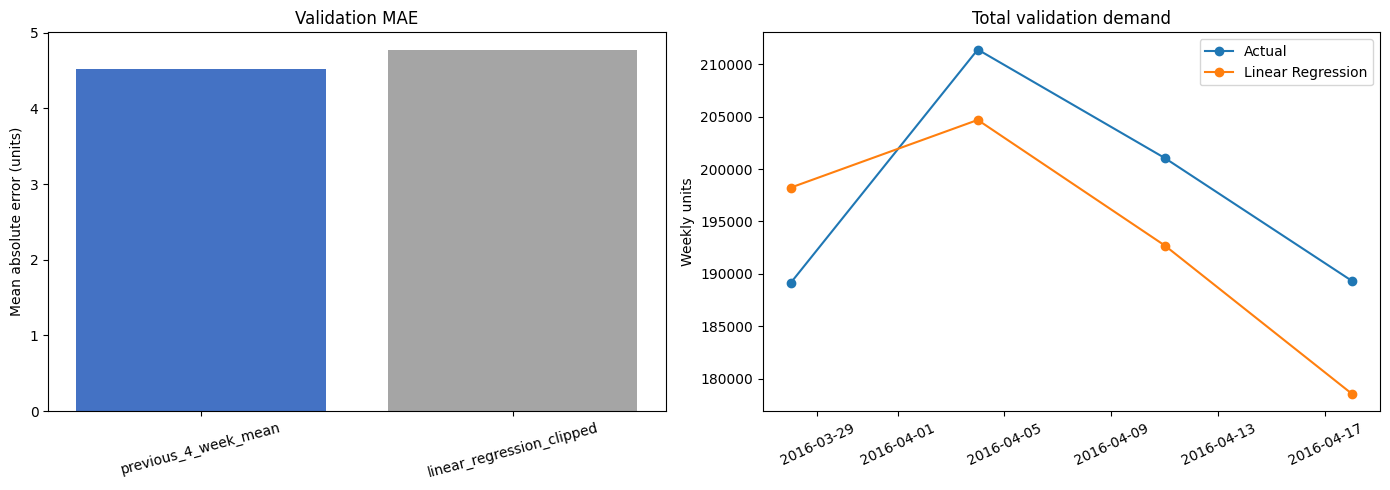

,feature,standardized_coefficient,absolute_coefficient
0,sales_roll_mean_8,4.7255,4.7255
1,sales_roll_mean_4,4.7118,4.7118
2,sales_lag_4,4.5270,4.5270
3,sales_lag_2,4.5248,4.5248
4,sales_lag_1,4.5001,4.5001
5,sales_lag_8,4.3420,4.3420
6,sales_roll_std_8,4.0135,4.0135
7,sales_roll_std_4,3.7924,3.7924
8,snap_days,0.4422,0.4422
9,has_snap,0.4285,0.4285


In [8]:
weekly = validation_results.groupby("week_start", as_index=False, observed=True).agg(
    actual_units=(target, "sum"),
    predicted_units=("prediction", "sum"),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(experiment_metrics["method"], experiment_metrics["mae"], color=["#4472C4", "#A5A5A5"])
axes[0].set_title("Validation MAE")
axes[0].set_ylabel("Mean absolute error (units)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].plot(weekly["week_start"], weekly["actual_units"], marker="o", label="Actual")
axes[1].plot(weekly["week_start"], weekly["predicted_units"], marker="o", label="Linear Regression")
axes[1].set_title("Total validation demand")
axes[1].set_ylabel("Weekly units")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()
display(coefficient_report.head(10))

## 9. Result

The experiment is reproducible through the saved notebook, reports, dependency versions, and local MLflow run. The model is not selected as final until it is compared with a course-appropriate tree model on the same validation period.